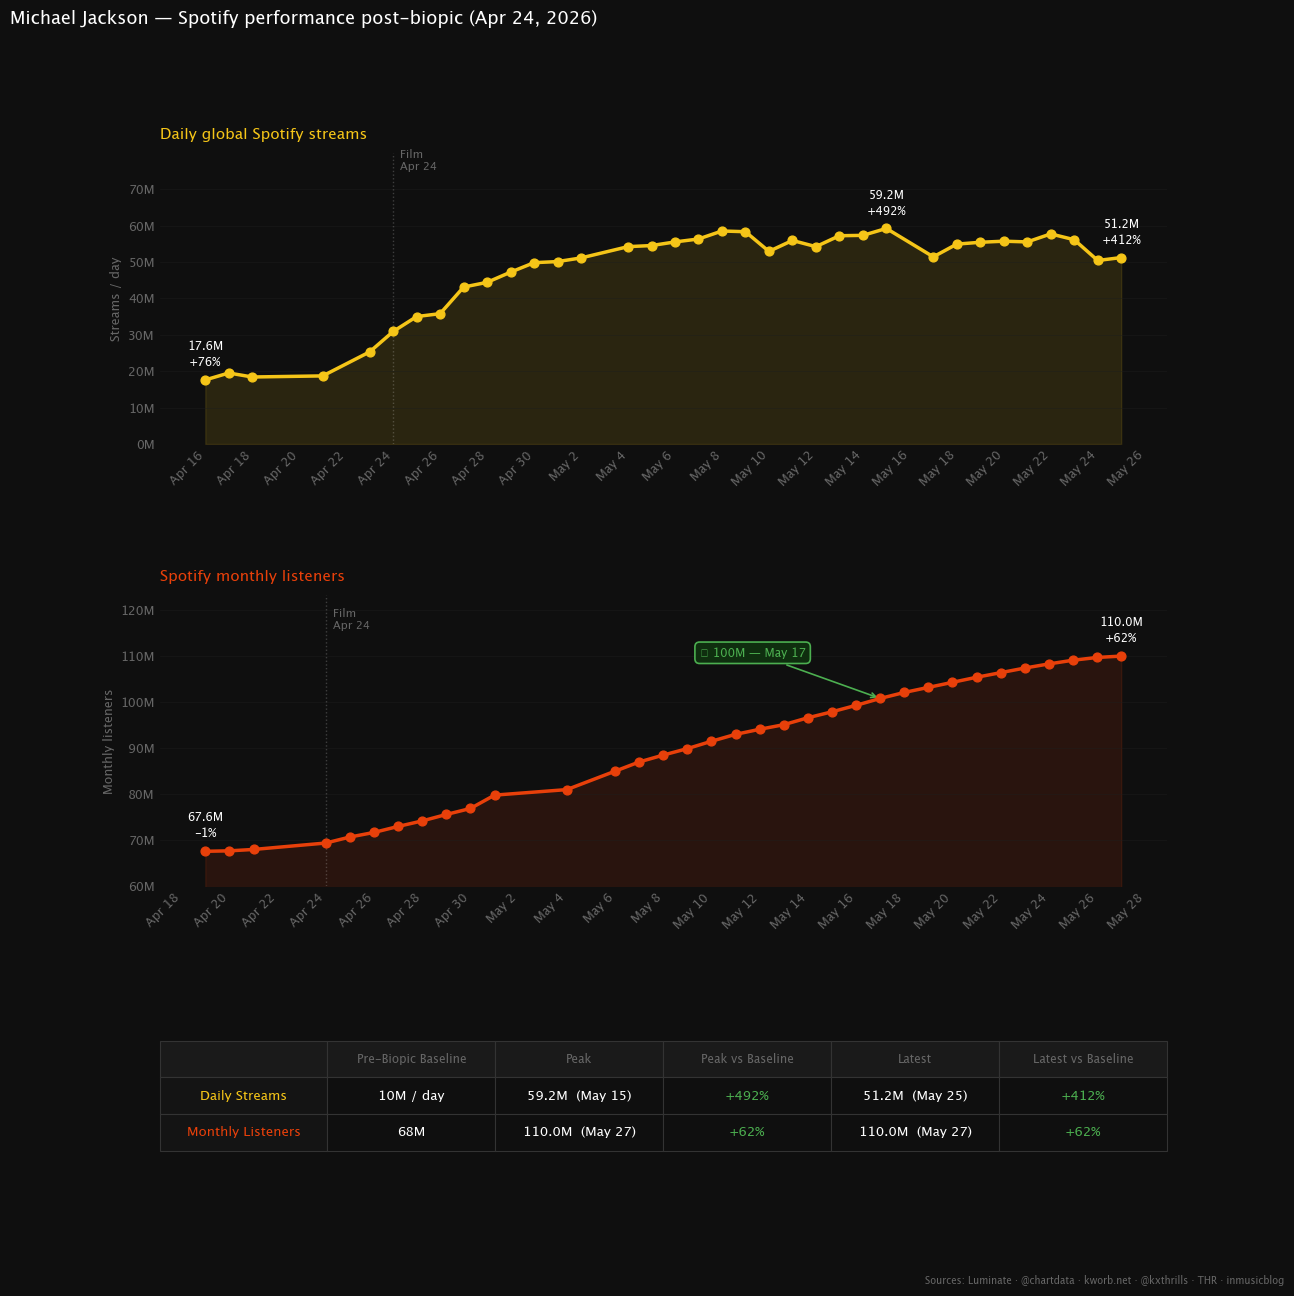

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# ─── UPDATE DAILY ────────────────────────────────────────────────────────────
# Sources: kworb.net/spotify/artist/3fMbdgg4jU18AjLCKBhRSm_songs.html
#          https://x.com/kxthrills
# Format:  ('YYYY-MM-DD', streams_millions_or_None, listeners_millions_or_None)
data = [
    ('2026-04-16', 17.6, None),
    ('2026-04-17', 19.5, None),
    ('2026-04-18', 18.4, None),
    ('2026-04-19', None, 67.6),
    ('2026-04-20', None, 67.7),
    ('2026-04-21', 18.7, 68.0),
    ('2026-04-23', 25.3, None),
    ('2026-04-24', 30.9, 69.4),
    ('2026-04-25', 35.0, 70.7),
    ('2026-04-26', 35.8, 71.7),
    ('2026-04-27', 43.1, 73.0),
    ('2026-04-28', 44.4, 74.2),
    ('2026-04-29', 47.2, 75.6),
    ('2026-04-30', 49.8, 76.9),
    ('2026-05-01', 50.1, 79.8),
    ('2026-05-02', 51.1, None),
    ('2026-05-04', 54.2, 81.0),
    ('2026-05-05', 54.5, None),
    ('2026-05-06', 55.5, 85.0),
    ('2026-05-07', 56.3, 87.0),
    ('2026-05-08', 58.5, 88.5),
    ('2026-05-09', 58.3, 89.9),
    ('2026-05-10', 52.9, 91.5),
    ('2026-05-11', 55.9, 93.0),
    ('2026-05-12', 54.2, 94.1),
    ('2026-05-13', 57.2, 95.1),
    ('2026-05-14', 57.3, 96.6),
    ('2026-05-15', 59.2, 97.9),
    ('2026-05-16', None, 99.3),
    ('2026-05-17', 51.4, 100.8),
    ('2026-05-18', 54.9, 102.1),
    ('2026-05-19', 55.4, 103.2),
    ('2026-05-20', 55.7, 104.3),
    ('2026-05-21', 55.5, 105.4),
    ('2026-05-22', 57.7, 106.4),
    ('2026-05-23', 56.1, 107.4),
    ('2026-05-24', 50.4, 108.3),
    ('2026-05-25', 51.2, 109.1,),
    ('2026-05-26', None, 109.7),
    ('2026-05-27', None, 110),
]
# ─────────────────────────────────────────────────────────────────────────────

YELLOW = '#F5C518'; RED = '#E8400A'; BG = '#0f0f0f'
GRID   = '#1e1e1e'; MUTED = '#666666'; WHITE = '#ffffff'; GREEN = '#4CAF50'
STREAMS_BASELINE = 10.0; LISTENERS_BASELINE = 68.0

def extract(data, idx):
    rows = sorted([(datetime.strptime(r[0], '%Y-%m-%d'), r[idx]) for r in data if r[idx] is not None])
    return [r[0] for r in rows], [r[1] for r in rows]

s_dates, s_values = extract(data, 1)
l_dates, l_values = extract(data, 2)

def pct_str(v, base):
    p = (v - base) / base * 100
    return f"{'+' if p >= 0 else ''}{p:.0f}%"

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.grid(axis='y', color=GRID, linewidth=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %-d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', color=MUTED, fontsize=9)
    plt.setp(ax.get_yticklabels(), color=MUTED, fontsize=9)

def plot_series(ax, dates, values, color, baseline, ylabel, title, ymin=0, ypad=1.35):
    ymax = max(values) * ypad
    ax.fill_between(dates, values, alpha=0.12, color=color)
    ax.plot(dates, values, color=color, linewidth=2.5, zorder=3)
    ax.scatter(dates, values, color=color, s=40, zorder=5)
    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
    ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.set_title(title, color=color, fontsize=11, fontweight='bold', pad=10, loc='left')

    peak_val = max(values)
    label_idx = {0, values.index(peak_val), len(values) - 1}
    for i, (d, v) in enumerate(zip(dates, values)):
        if i in label_idx:
            ax.annotate(f'{v:.1f}M\n{pct_str(v, baseline)}', xy=(d, v), xytext=(0, 10),
                        textcoords='offset points', ha='center', fontsize=8.5,
                        color=WHITE, fontweight='bold', linespacing=1.4)

    ax.axvline(x=datetime(2026, 4, 24), color=WHITE, linewidth=1, linestyle=':', alpha=0.2)
    ax.text(datetime(2026, 4, 24), ymax * 0.94, '  Film\n  Apr 24', color=MUTED, fontsize=8)
    return ymax

# ── Build figure ──────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 13),
                                     gridspec_kw={'height_ratios': [3, 3, 1.2]})
fig.patch.set_facecolor(BG)
fig.subplots_adjust(hspace=0.65)

style_ax(ax1)
plot_series(ax1, s_dates, s_values, YELLOW, STREAMS_BASELINE,
            'Streams / day', 'Daily global Spotify streams')

style_ax(ax2)
plot_series(ax2, l_dates, l_values, RED, LISTENERS_BASELINE,
            'Monthly listeners', 'Spotify monthly listeners', ymin=60, ypad=1.12)

# ── 100M milestone box ────────────────────────────────────────────────────────
ax2.annotate('🎯 100M — May 17',
             xy=(datetime(2026, 5, 17), 100.8),
             xytext=(-130, 30), textcoords='offset points',
             fontsize=8.5, color=GREEN, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#0f2e0f',
                       edgecolor=GREEN, linewidth=1.2),
             arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.2))

fig.suptitle('Michael Jackson — Spotify performance post-biopic (Apr 24, 2026)',
             color=WHITE, fontsize=13, fontweight='bold', x=0.01, ha='left', y=0.99)
fig.text(0.99, 0.01, 'Sources: Luminate · @chartdata · kworb.net · @kxthrills · THR · inmusicblog',
         ha='right', fontsize=7, color=MUTED)

# ── Summary table ─────────────────────────────────────────────────────────────
s_peak_val  = max(s_values);  s_peak_date = s_dates[s_values.index(s_peak_val)]
l_peak_val  = max(l_values);  l_peak_date = l_dates[l_values.index(l_peak_val)]

col_labels = ['', 'Pre-Biopic Baseline', 'Peak', 'Peak vs Baseline', 'Latest', 'Latest vs Baseline']
table_data = [
    [f'{STREAMS_BASELINE:.0f}M / day',
     f"{s_peak_val:.1f}M  ({s_peak_date:%b %-d})",   pct_str(s_peak_val,  STREAMS_BASELINE),
     f'{s_values[-1]:.1f}M  ({s_dates[-1]:%b %-d})', pct_str(s_values[-1], STREAMS_BASELINE)],
    [f'{LISTENERS_BASELINE:.0f}M',
     f"{l_peak_val:.1f}M  ({l_peak_date:%b %-d})",   pct_str(l_peak_val,  LISTENERS_BASELINE),
     f'{l_values[-1]:.1f}M  ({l_dates[-1]:%b %-d})', pct_str(l_values[-1], LISTENERS_BASELINE)],
]
row_labels = ['Daily Streams', 'Monthly Listeners']

ax3.set_facecolor(BG)
ax3.axis('off')
tbl = ax3.table(
    cellText=[[row_labels[i]] + table_data[i] for i in range(2)],
    colLabels=col_labels, cellLoc='center', loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 2.2)

for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor(BG)
    cell.set_edgecolor('#333333')
    cell.set_linewidth(0.8)
    cell.set_text_props(color=WHITE)
    if row == 0:
        cell.set_facecolor('#1a1a1a')
        cell.set_text_props(color=MUTED, fontsize=8.5, fontweight='bold')
    if col == 0 and row > 0:
        cell.set_facecolor('#141414')
        cell.set_text_props(color=YELLOW if row == 1 else RED, fontweight='bold')
    if col in (3, 5) and row > 0:
        cell.set_text_props(color=GREEN, fontweight='bold')

plt.show()